# Simple Pendulum as Co-Simulation Component

## Overview
In this tutorial we will get familiar with the basics of the system simulation framework by implementing a simple pendulum model as a co-simulation component.

We will use the base class `CoSimComponent` to create our pendulum model. This class provides the necessary interface for co-simulation components, including methods for configuration, initialization, time-stepping, and result retrieval.

## Learning Goals

- Understand the minimal structure of a CoSimComponent
- Understand how to implement a simple physical model (pendulum) as a CoSimComponent
- Execute a single component simulation and inspect time-series outputs

## Prerequisites and Setup

- You have installed `syssimx` and its Python dependencies
- You are comfortable running Jupyter Notebook cells
- This tutorial is self-contained and does not require any FMU files

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt

from syssimx import CoSimComponent, Connection, System
from syssimx.core.port import PortSpec, PortType
from syssimx.utilities import Quantity

## Mathematical Derivation

We consider a simple pendulum consisting of a mass $m$, with distance $L_{cm}$ from the pivot to the center of mass, and an inertia $I$ about the pivot point.

The state of the pendulum can be described by its angle $\theta$ (measured from the vertical) and its angular velocity $\dot{\theta}$.

For now we only condsider the gravitational force acting on the pendulum, neglecting any damping or external forces.

The equations of motion for the pendulum can be derived using Newton's second law.

\begin{align*}
F &= m \cdot a \\
\tau &= I \cdot \alpha \\
\end{align*}

where $F$ is the force, $a$ is the linear acceleration, $\tau$ is the torque, and $\alpha$ is the angular acceleration.

The torque acting on the pendulum due to gravity is given by:
\begin{align*}
\tau &= -m \cdot g \cdot L_{cm} \cdot \sin(\theta)
\end{align*}

The angular acceleration $\alpha$ can be expressed as:
\begin{align*}
\alpha = \frac{\partial^2 \theta}{\partial t^2} = \frac{\tau}{I} = -\frac{m \cdot g \cdot L_{cm}}{I} \cdot \sin(\theta)
\end{align*}

We can rewrite this second-order differential equation as a system of first-order differential equations by introducing the angular velocity $\omega = \dot{\theta}$:
\begin{align*}
\frac{\partial \theta}{\partial t} &= \omega \\
\frac{\partial \omega}{\partial t} &= -\frac{m \cdot g \cdot L_{cm}}{I} \cdot \sin(\theta)
\end{align*}

This system of equations describes the dynamics of the simple pendulum under the influence of gravity. It is an example of a initial value problem (IVP) that can be solved numerically using various integration methods.

![PendulumFigure](../figures/Pendulum_gravity.svg)

**Figure:** A simple pendulum under the influence of gravity. Source: [Wikipedia](https://en.wikipedia.org/wiki/Pendulum_(mechanics)#/media/File:Pendulum_gravity.svg)

## Model Definition

The time variable $t$ will be the independent variable, while the state variables will be:
- $\theta$ : Angle of the pendulum (radians)
- $\omega$ : Angular velocity of the pendulum (radians per second)

The angular acceleration $\alpha$ will be computed based on the current state of the pendulum using the derived equations of motion.

The initial conditions for the simulation will be:
- $\theta(t=0) = \theta_0$ : Initial angle (radians)
- $\omega(t=0) = 0$ : Initial angular velocity (radians per second)

The initial conditions define the starting state of the pendulum at the beginning of the simulation and provide information to find the unique solution to the differential equations.

This model does not have any external inputs or outputs, as it is a standalone pendulum system. The simulation will compute the evolution of the state variables over time based on the initial conditions and the equations of motion.



## Implementation as CoSimComponent

The framework allows the use of physical quantities with units. We will define the parameters of the pendulum model using the `Quantity` class to ensure proper unit handling. The unit handling is based on the `pint` library.

To record and keep track of the state trajectories during simulation, we will define output ports for the angular position $\theta$, angular velocity $\omega$, and angular acceleration $\alpha$ of the pendulum. These output ports will allow us to monitor and analyze the behavior of the pendulum over time. 

### 3.1 Define the Pendulum Component Class

**Construction:**
- The `SimplePendulum` class inherits from `CoSimComponent` which provides the necessary interface and common functionality for co-simulation components.
- The `__init__` method initializes the component with a name and sets up the parameters, state variables, and output ports.
- As desscribed above, the parameters are defined using the `Quantity` class to ensure proper unit handling.

**Component Initialization:**
- The `_initialize_component` method is called during the initialization phase of the component. It sets the initial state of the pendulum based on the provided initial angle and angular velocity. It also uses the `_pendulum_dynamics` method to compute the initial angular acceleration.

**Pendulum Dynamics:**
- We define the system of equations in the internal method `_pendulum_dynamics` which computes the derivatives of the state variables based on the current state and parameters.

**Time Stepping:**
- The `do_step` method is responsible for advancing the simulation by a specified time step `dt`.
- The method `_do_step_internal` is called from the base class and performs the actual time-stepping logic. The method needs to be implemented in the derived class.
- We are using the function `solve_ivp` from `scipy.integrate` to perform the numerical integration of the pendulum's equations of motion during each time step.
- After the internal time stepping returns, the base class `do_step` method calls `_update_output_states` to update the output port values with the current state of the pendulum.
-Furthermore, the base class adds the current output values to the history for later retrieval.

**Update Output States:**
- The `_update_output_states` method updates the output port states with the current values of the state variables after each time step.
- After this method is called, the output ports will contain the latest values of $\theta$, $\omega$, and $\alpha$ which can be accessed by other components or for logging purposes.

**Resetting the Component:**
- The `reset` method resets the component to its initial state, allowing for re-simulation without needing to recreate the component instance.
- It calls the base class `reset` to reset the simulation time `component.t` and clear the component history.



In [2]:
class SimplePendulum(CoSimComponent):

    def __init__(self, name, label = None, group = None):
        super().__init__(name, label, group)

        # Initialize internal variables
        self._theta = 0.0  # Angular position (rad)
        self._omega = 0.0  # Angular velocity (rad/s)
        self._alpha = 0.0  # Angular acceleration (rad/s^2)
        
        # Define Output Ports
        self.output_specs.update({
            "theta": PortSpec(name="theta", type=PortType.REAL, direction="out", unit="rad"),
            "omega": PortSpec(name="omega", type=PortType.REAL, direction="out", unit="rad/s"),
            "alpha": PortSpec(name="alpha", type=PortType.REAL, direction="out", unit="rad/s^2")
        })
        # Set Default Parameter Values
        self._set_default_parameter_values()

    def _set_default_parameter_values(self):
        self.parameters.update({
            "length":  Quantity(0.6, "m"),       # Length of the pendulum rod (m)
            "mass":    Quantity(40, "kg"),      # Mass of the pendulum bob (kg)
            "inertia": Quantity(20, "kg*m^2"),  # Moment of inertia (kg*m^2)
            "gravity": Quantity(9.81, "m/s^2"),  # Gravitational acceleration (m/s^2)
            "q0":      Quantity(0.3, "rad"), # Initial angle (rad)
            "omega0":  Quantity(0.0, "rad/s")    # Initial angular velocity (rad/s)
        })
    
    def _pendulum_dynamics(self, y: np.ndarray):
        theta, omega = y
        m = self.parameters["mass"].magnitude
        g = self.parameters["gravity"].magnitude
        L = self.parameters["length"].magnitude
        I = self.parameters["inertia"].magnitude

        alpha = -(m * g * L * np.sin(theta)) / I
        return np.array([omega, alpha])
        
    def _initialize_component(self, t0):
        # Set initial conditions
        self._theta = self.parameters["q0"].magnitude
        self._omega = self.parameters["omega0"].magnitude
        y = np.array([self._theta, self._omega])
        self._alpha = self._pendulum_dynamics(y)[1]
    
    def _update_output_states(self, t = None, event_names = ...):
        self.outputs['theta'].set(self._theta)
        self.outputs['omega'].set(self._omega)
        self.outputs['alpha'].set(self._alpha)

    def _do_step_internal(self, t, dt):
        """Solve pendulum ODE over [t, t+dt]."""
        y0 = np.array([self._theta, self._omega])
        
        sol = solve_ivp(
            fun=lambda t, y: self._pendulum_dynamics(y),
            t_span=[t, t + dt],
            y0=y0,
            method='RK45',
            t_eval=[t + dt]
        )
        
        self._theta, self._omega = sol.y[:, -1]
        self._alpha = self._pendulum_dynamics(np.array([self._theta, self._omega]))[1]

    def reset(self):
        super().reset()

        self.parameters.clear()
        self._set_default_parameter_values()

        self._theta = 0.0
        self._omega = 0.0
        self._alpha = 0.0

### Create an Instance of the Pendulum Component

In [3]:
pendulum = SimplePendulum("MyFirstPendulum")

### Obtain and Print Pendulum Defaulr Parameters

In [4]:
params = pendulum.get_parameters()
print("Default Parameters:")
for key, value in params.items():
    print(f"{key:>10}: {value.magnitude:.4f} {value.units}")

Default Parameters:
    length: 0.6000 m
      mass: 40.0000 kg
   inertia: 20.0000 kg·m²
   gravity: 9.8100 m/s²
        q0: 0.3000 rad
    omega0: 0.0000 rad/s


### Initialize the Pendulum Component

In [5]:
pendulum.initialize(t0=0.0)

### Run the Simulation

The simulation will be run for a total duration of 2 seconds with a time step of 0.001 seconds. During each time step, the `do_step` method of the pendulum component will be called to advance the simulation and update the state variables accordingly.

In [6]:
time_end = 5
dt = 0.01
time_points = np.arange(0.0, time_end, dt)
for t in time_points:
    pendulum.do_step(t, dt)

### Retrieving History and Plotting Results

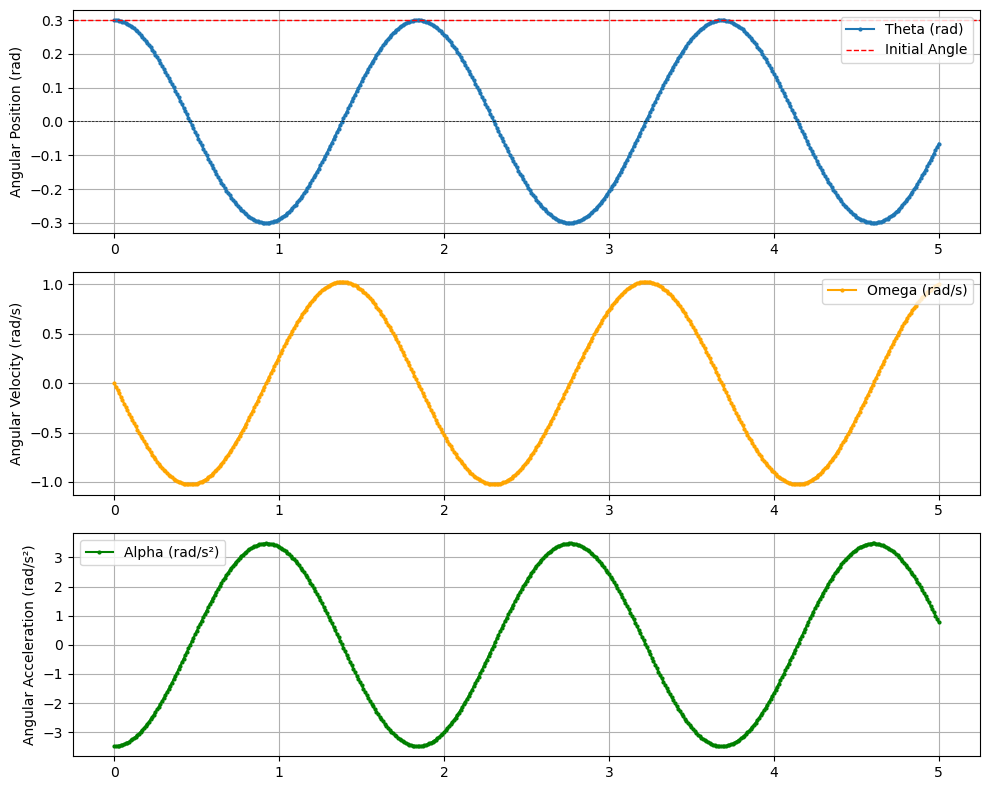

In [7]:
history = pendulum.get_history()

times = history["theta"]['time']
thetas = history["theta"]['values']
omegas = history["omega"]['values']
alphas = history["alpha"]['values']

style = {'marker': 'o', 'markersize': 2, 'linestyle': '-'}
plt.figure(figsize=(10, 8))
plt.subplot(3, 1, 1)
plt.plot(times, thetas, label='Theta (rad)', **style)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axhline(pendulum.parameters["q0"], color='red', linewidth=1, linestyle='--', label='Initial Angle')
plt.grid()
plt.legend(loc='upper right')
plt.ylabel('Angular Position (rad)')

plt.subplot(3, 1, 2)
plt.plot(times, omegas, label='Omega (rad/s)', color='orange', **style)
plt.grid()
plt.legend(loc='upper right')
plt.ylabel('Angular Velocity (rad/s)')

plt.subplot(3, 1, 3)
plt.plot(times, alphas, label='Alpha (rad/s²)', color='green', **style)
plt.grid()
plt.legend(loc='upper right')
plt.ylabel('Angular Acceleration (rad/s²)')

plt.legend()
plt.tight_layout()
plt.show()

## Comparing Different Pendulum Parameter Configurations

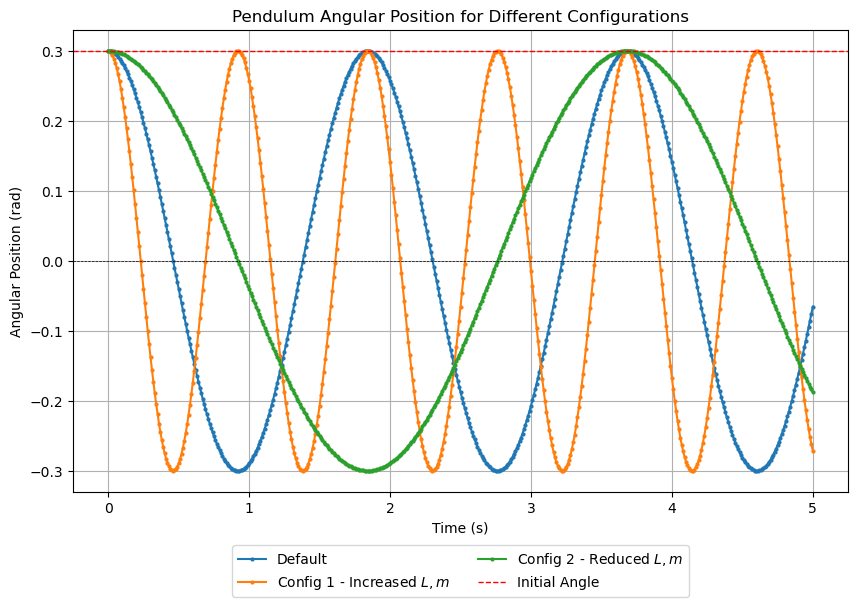

In [8]:
default_config = pendulum.get_parameters()

config1 = {
    'length': 2 * default_config['length'],
    'mass': 2 * default_config['mass'],
}

config2 = {
    'length': 0.5 * default_config['length'],
    'mass': 0.5 * default_config['mass']
}

labels = ['Default', 'Config 1 - Increased $L, m$', 'Config 2 - Reduced $L, m$']
configs = [default_config, config1, config2]
histories = []


for i, config in enumerate(configs):
    pendulum.reset()
    pendulum.set_parameters(**config)
    
    pendulum.initialize(t0=0.0)
    for t in time_points:
        pendulum.do_step(t, dt)
    
    histories.append(pendulum.get_history())

plt.figure(figsize=(10, 6))
for i, history in enumerate(histories):
    times = history["theta"]['time']
    thetas = history["theta"]['values']
    plt.plot(times, thetas, label=labels[i], **style)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axhline(pendulum.parameters["q0"], color='red', linewidth=1, linestyle='--', label='Initial Angle')
plt.title('Pendulum Angular Position for Different Configurations')
plt.xlabel('Time (s)')
plt.ylabel('Angular Position (rad)')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.grid()

This comparison allows us to observe how changes in the pendulum's physical parameters affect its dynamic behavior. By analyzing the results, we can gain insights into the influence of mass, length, and inertia on the pendulum's motion.

-----------------

## Summary and Next Steps

In this first tutorial, we implemented a simple pendulum model as a co-simulation component using the `CoSimComponent` base class.
We defined the pendulum's equations of motion, set up the necessary parameters and output ports, and executed a time-stepped simulation to observe the pendulum's behavior over time.

It might be seen now a bit unclear why we have a `CoSimComponent` for a standalone pendulum without any connections to other components and require all the methods of the base class.
However, this structure sets the foundation for more complex simulations where the pendulum could interact with other components in a co-simulation environment.

It might also be the case that we do not want to create physical components as the `SimplePendulum` natively in Python using `scipy.integrate.solve_ivp` for solving the ODEs. We might be interested in modeling such model using `Modelica` and then export it as an FMU for Co-Simulation. This will be covered in the next tutorials.